<a href="https://colab.research.google.com/github/JJJuniorDev/ML-colab/blob/main/larger_example_nn_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
insurance=pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")

In [15]:
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
#one hot encoding per renderli tutti numeri
insurance_one_hot=pd.get_dummies(insurance, dtype=int)

In [5]:
X=insurance_one_hot.drop("charges", axis=1)
y=insurance_one_hot["charges"]
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=["mae"])
history=insurance_model.fit(X_train, y_train, epochs=500)

Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13270.4033 - mae: 13270.4033
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13223.7979 - mae: 13223.7979 
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13156.2236 - mae: 13156.2236
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13058.3291 - mae: 13058.3291 
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12920.8955 - mae: 12920.8955 
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12733.3174 - mae: 12733.3174 
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12482.9766 - mae: 12482.9766
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12155.6641 - mae: 12155.6641
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11738.6816 - mae: 11738.6816
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11223.4316 - mae: 11223.4316
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10622.0986 - mae: 10622.0986
Epoch 12/500
34/34 ━━━━━━━

In [8]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3400.4878 - mae: 3400.4878  


[3334.146728515625, 3334.146728515625]

Text(0.5, 0, 'epochs')

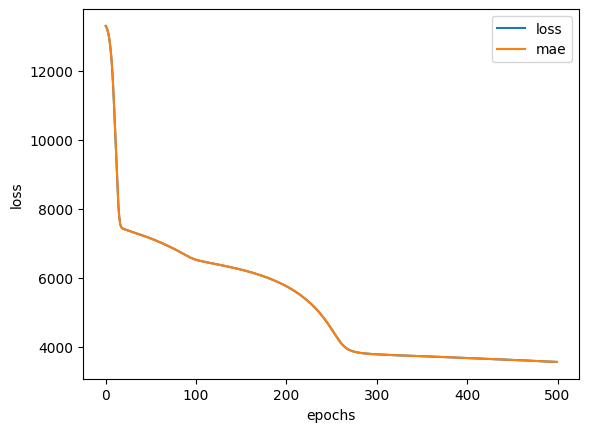

In [9]:
#plot history (loss curve o training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

In [7]:
#normalizzazione
#per scalare i valori nelle NN si preferisce usare normalizzazione
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

#creiamo un column transformer
ct= make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]),#trasformo tra 0 e 1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
                            )


In [8]:
#fittiamo il column transformer al nostro training data
ct.fit(X_train)
#trasformiamo training e test data con normalizzazione
X_train_normal=ct.transform(X_train)
X_test_normal=ct.transform(X_test)

In [10]:
X_train.loc[0], X_train_normal[0]

(age                19
 sex            female
 bmi              27.9
 children            0
 smoker            yes
 region      southwest
 Name: 0, dtype: object,
 array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
        1.        , 0.        , 0.        , 1.        , 0.        ,
        0.        ]))

In [11]:
X_train.shape, X_train_normal.shape #aumentano le dimensioni

((1070, 6), (1070, 11))

In [14]:
ins_model= tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
ins_model.compile(loss=tf.keras.losses.mae,
                  optimizer=tf.keras.optimizers.Adam(),
                  metrics=["mae"])

history=ins_model.fit(X_train_normal, y_train, epochs=500)

Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 12790.2324 - mae: 12790.2324
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13335.5293 - mae: 13335.5293
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13330.5498 - mae: 13330.5498
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13147.0830 - mae: 13147.0830
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13357.0322 - mae: 13357.0322
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13080.4678 - mae: 13080.4678
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 12762.2617 - mae: 12762.2617
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 12792.1387 - mae: 12792.1387
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13249.2363 - mae: 13249.2363
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 13997.5566 - mae: 13997.5566
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13163.5381 - mae: 13163.5381
Epoch 12/500
34/34 ━━━━━━━

In [15]:
ins_model.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3215.6887 - mae: 3215.6887  


[3161.48046875, 3161.48046875]